# Module-12: Predicting Short-Horizon Up-Move Probability with Ensembles

This notebook builds mock financial OHLCV data and trains complementary model families (linear, tree-based, boosting) to predict the probability of an up-move on the next period. We also ensemble their probabilities and compare performance.

Kernel: select "Python (Module-12)" from the kernel menu after opening the notebook.


In [1]:
# Imports and configuration
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

np.random.seed(42)
plt.style.use('seaborn-v0_8')
sns.set_context('talk')

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 50)



In [2]:
# Generate mock OHLCV data (random walk with volatility clusters)

n = 3000  # observations
mu = 0.0002  # drift per step
base_sigma = 0.01

# Volatility regime switching
t = np.arange(n)
regime = (np.sin(t / 200.0) > 0).astype(float)  # oscillating regimes
sigma = base_sigma * (0.6 + 1.2 * regime)  # higher vol in positive regime

# Random walk log prices
shocks = np.random.normal(loc=mu, scale=sigma)
log_price = np.cumsum(shocks) + 5.0
price = np.exp(log_price)

# Build OHLCV
close = price
open_ = np.concatenate([[price[0]], price[:-1]])
high = np.maximum(open_, close) * (1 + np.random.uniform(0, 0.002, size=n))
low = np.minimum(open_, close) * (1 - np.random.uniform(0, 0.002, size=n))
volume = (1e6 * (1 + 0.3 * regime) * np.random.lognormal(mean=0.0, sigma=0.3, size=n)).astype(int)

df = pd.DataFrame({
    'open': open_, 'high': high, 'low': low, 'close': close, 'volume': volume
})

df.head()


,open,high,low,close,volume
0,148.885907,149.129704,148.820579,148.885907,1122673
1,148.885907,149.178785,148.407578,148.545533,1019586
2,148.545533,150.395596,148.416818,150.317530,1989881
3,150.317530,154.826019,150.077114,154.526323,1419592
4,154.526323,154.659597,153.679560,153.907181,1618192


In [3]:
# Feature engineering

# Log returns and next-step label (1 if up, else 0)
df['log_ret'] = np.log(df['close']).diff()
df['y_up_next'] = (df['log_ret'].shift(-1) > 0).astype(int)

# Rolling features (avoid lookahead)
window_short = 10
window_long = 50

df['ret_roll_mean_s'] = df['log_ret'].rolling(window_short).mean()
df['ret_roll_std_s'] = df['log_ret'].rolling(window_short).std()
df['ret_roll_mean_l'] = df['log_ret'].rolling(window_long).mean()

# Momentum proxy
df['mom_20'] = df['close'].pct_change(20)

# RSI-like proxy
chg = df['close'].diff()
up = chg.clip(lower=0)
dn = -chg.clip(upper=0)
rs = (up.rolling(14).mean()) / (dn.rolling(14).mean() + 1e-9)
df['rsi'] = 100 - 100 / (1 + rs)

# Volume z-score
log_vol = np.log(df['volume'] + 1)
df['vol_z'] = (log_vol - log_vol.rolling(50).mean()) / (log_vol.rolling(50).std() + 1e-9)

# Drop initial NaNs
df_ml = df.dropna().copy()

features = ['ret_roll_mean_s','ret_roll_std_s','ret_roll_mean_l','mom_20','rsi','vol_z']
X = df_ml[features].values
y = df_ml['y_up_next'].values

X.shape, y.shape


((2950, 6), (2950,))

In [4]:
# Time-aware split (train/valid/test) to avoid leakage
n_total = len(df_ml)
train_end = int(n_total * 0.6)
valid_end = int(n_total * 0.8)

X_train, y_train = X[:train_end], y[:train_end]
X_valid, y_valid = X[train_end:valid_end], y[train_end:valid_end]
X_test,  y_test  = X[valid_end:], y[valid_end:]

X_train.shape, X_valid.shape, X_test.shape


((1770, 6), (590, 6), (590, 6))

In [5]:
# Train models: Logistic Regression, Random Forest, XGBoost

# Linear model
lr = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=None)
lr.fit(X_train, y_train)

# Tree-based
rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Boosting
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
)
xgb.fit(X_train, y_train)

print('Models trained.')


Models trained.


In [6]:
# Evaluate each model on validation and test
from sklearn.metrics import classification_report

def eval_model(model, Xv, yv, name='model'):
    p = model.predict_proba(Xv)[:,1]
    yhat = (p >= 0.5).astype(int)
    acc = accuracy_score(yv, yhat)
    auc = roc_auc_score(yv, p)
    print(f"{name}: ACC={acc:.3f} AUC={auc:.3f}")
    return p, acc, auc

print('Validation:')
p_lr_v, acc_lr_v, auc_lr_v = eval_model(lr, X_valid, y_valid, 'LogReg')
p_rf_v, acc_rf_v, auc_rf_v = eval_model(rf, X_valid, y_valid, 'RandomForest')
p_xgb_v, acc_xgb_v, auc_xgb_v = eval_model(xgb, X_valid, y_valid, 'XGBoost')

print('\nTest:')
p_lr_t, acc_lr_t, auc_lr_t = eval_model(lr, X_test, y_test, 'LogReg')
p_rf_t, acc_rf_t, auc_rf_t = eval_model(rf, X_test, y_test, 'RandomForest')
p_xgb_t, acc_xgb_t, auc_xgb_t = eval_model(xgb, X_test, y_test, 'XGBoost')


Validation:
LogReg: ACC=0.461 AUC=0.462
RandomForest: ACC=0.480 AUC=0.459
XGBoost: ACC=0.461 AUC=0.457

Test:
LogReg: ACC=0.519 AUC=0.496
RandomForest: ACC=0.488 AUC=0.495
XGBoost: ACC=0.512 AUC=0.532


In [7]:
# Simple ensemble: average of probabilities
p_ens_v = (p_lr_v + p_rf_v + p_xgb_v) / 3
p_ens_t = (p_lr_t + p_rf_t + p_xgb_t) / 3

acc_ens_v = accuracy_score(y_valid, (p_ens_v>=0.5).astype(int))
auc_ens_v = roc_auc_score(y_valid, p_ens_v)
acc_ens_t = accuracy_score(y_test, (p_ens_t>=0.5).astype(int))
auc_ens_t = roc_auc_score(y_test, p_ens_t)

print(f"Ensemble Validation: ACC={acc_ens_v:.3f} AUC={auc_ens_v:.3f}")
print(f"Ensemble Test:       ACC={acc_ens_t:.3f} AUC={auc_ens_t:.3f}")


Ensemble Validation: ACC=0.451 AUC=0.452
Ensemble Test:       ACC=0.500 AUC=0.520


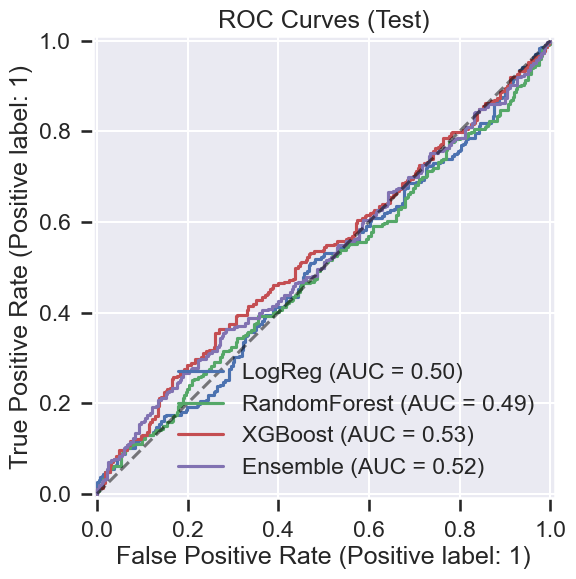

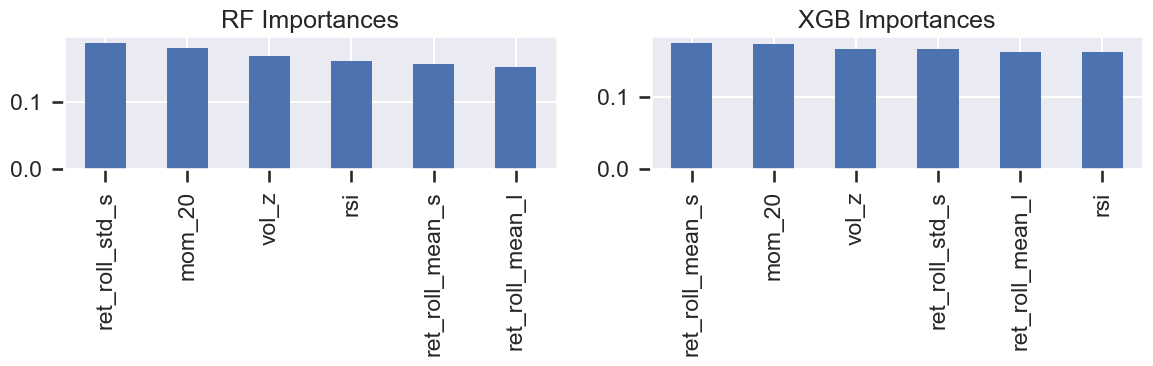

In [8]:
# Plot ROC curves on test
fig, ax = plt.subplots(figsize=(7,6))
RocCurveDisplay.from_predictions(y_test, p_lr_t, name='LogReg', ax=ax)
RocCurveDisplay.from_predictions(y_test, p_rf_t, name='RandomForest', ax=ax)
RocCurveDisplay.from_predictions(y_test, p_xgb_t, name='XGBoost', ax=ax)
RocCurveDisplay.from_predictions(y_test, p_ens_t, name='Ensemble', ax=ax)
ax.plot([0,1],[0,1],'k--',alpha=0.5)
ax.set_title('ROC Curves (Test)')
plt.show()

# Optional: feature importance from RF/XGB
fig, axes = plt.subplots(1,2, figsize=(12,4))
imp_rf = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
imp_rf.plot(kind='bar', ax=axes[0], title='RF Importances')
imp_xgb = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)
imp_xgb.plot(kind='bar', ax=axes[1], title='XGB Importances')
plt.tight_layout()
plt.show()
